# Recurrent Neural Networks

<a rel="license" href="http://creativecommons.org/licenses/by-nc-sa/4.0/"><img alt="Creative Commons License" align="left" src="https://i.creativecommons.org/l/by-nc-sa/4.0/80x15.png" /></a>&nbsp;| Dennis G. Wilson | <a href="https://supaerodatascience.github.io/deep-learning/">https://supaerodatascience.github.io/deep-learning/</a>
Updates by G. Durantin 2021

## Time series forecasting (EEG data)

Today, we'll look at a simple example of time series forecasting. This family of algorithms can be used for a variety of prediction tasks, such as [predicting stock prices](https://arxiv.org/pdf/1911.13288.pdf) and [seizure prediction](https://www.sciencedirect.com/science/article/pii/S001048251830132X). We'll focus on the use of Recurrent Neural Networks in this context.

The data we'll use today is a set of EEG readings used to study seizures. You can find the data [here](https://physionet.org/content/chbmit/1.0.0/), and in the `data` directory there is a single patient recording `chb01_chb01_03.edf` which includes a seizure episode. We won't focus on seizure detection today but will instead try to predict neural activity.

These files are stored in the European Data Format, https://www.edfplus.info/. We'll use the python library `pyedflib` to read them. To use Colab, uncomment the following lines.

In [3]:
#!pip install pyedflib
#!wget https://github.com/SupaeroDataScience/deep-learning/blob/main/RNN/data/chb01_chb01_03.edf?raw=true
#!mkdir data 
#!mv chb01_chb01_03.edf?raw=true data/chb01_chb01_03.edf

In [ ]:
# Imports
import os
import pyedflib
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_squared_error

import statsmodels.api as sm


import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
#Reading files
file_name = os.path.join('data','chb01_chb01_03.edf')
f = pyedflib.EdfReader(file_name)

In [6]:
n = f.signals_in_file
labels = f.getSignalLabels()
print('%d different signals: %s' % (n, str(labels)))

23 different signals: ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8']


The file we are reading contains 23 signals created using the data from electrodes on the scalp. 

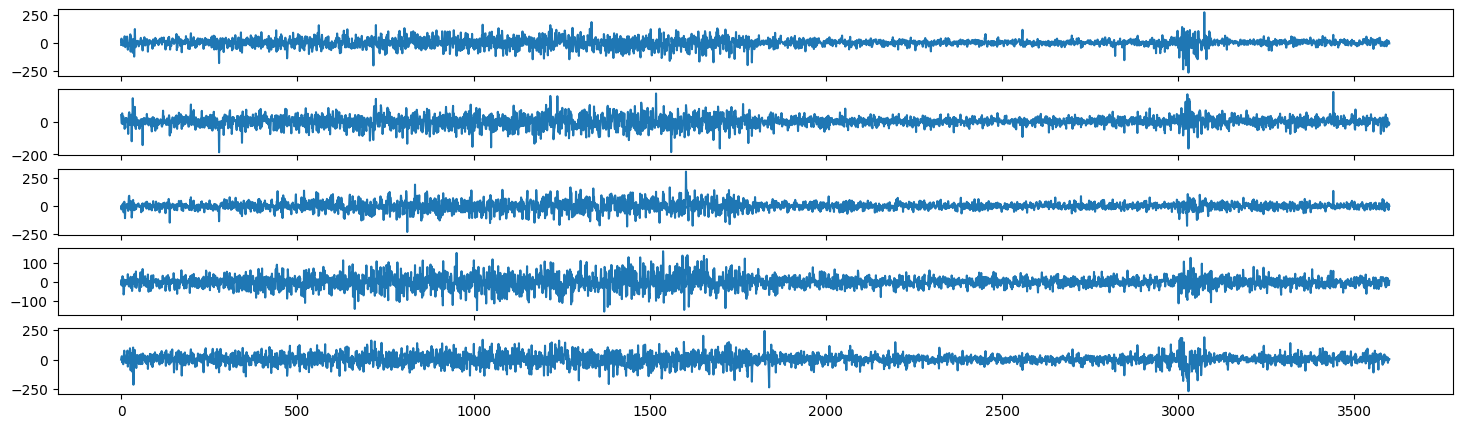

In [7]:
fig, axs = plt.subplots(5, sharex=True, figsize=(18,5))
for i in range(5):
    signal = f.readSignal(i)
    axs[i].plot(signal[::256])

As we can see, this single recording contains 23 different signals from different sensors placed on the scalp. We'll focus at predicting a single signal. Our first data processing step is normalizing the data. This is beneficial for recurrent neural network training, but does require domain knowledge. In this case, we know the physical limits of the sensors, so we can use that to normalize the data between $[-1, 1]$.

In [8]:
signal = f.readSignal(0)
signal = 2 * (signal - f.physical_min(0)) / (f.physical_max(0) - f.physical_min(0)) - 1.0

Another preparation often done with timeseries data is to check if it is **stationary**, ie if the mean and variance change over time. To do this, we'll use the [Dickey-Fuller test](https://en.wikipedia.org/wiki/Dickey%E2%80%93Fuller_test). This test can be very costly to compute, so we'll downsample the data. There are 256 samples per second in this data, so we'll take one sample each second.

In [ ]:
p_value = sm.tsa.stattools.adfuller(signal[::256])[1]
p_value

np.float64(9.655290037084316e-30)

The small value means that the timeseries **is stationary**. This isn't a necessary condition for LSTMs, but it will help training. When the timeseries is not stationary (`p_value > 0.05`), it's normal to instead predict the **difference** between timesteps, ie $$y_t - y_{t-1}$$ which can be calculated in numpy using `diff` and in pandas with `shift`.

Finally, we split our data into training and test sets, preserving order:

In [10]:
s_max = 1000
data = np.zeros((6, s_max))
for i in range(6):
    signal = f.readSignal(i)
    signal = 2 * (signal - f.physical_min(i)) / (f.physical_max(i) - f.physical_min(i)) - 1.0
    data[i, :] = signal[:s_max]

# très mauvaise manière de construire les train/test sets
# chaque ligne correspond à une électrode, chaque colonne au temps, donc ici on sépare les électrodes en deux types
# chaque ligne est un signal différent
train_input = torch.from_numpy(data[:3, :])
test_input = torch.from_numpy(data[3:7, :])

# probablement mieux : couper le temps en deux ? entraine un potentiel risque métier (une expérience qui varie en fonction du temps)

In [11]:
print(train_input.shape)
print(test_input.shape)

torch.Size([3, 1000])
torch.Size([3, 1000])


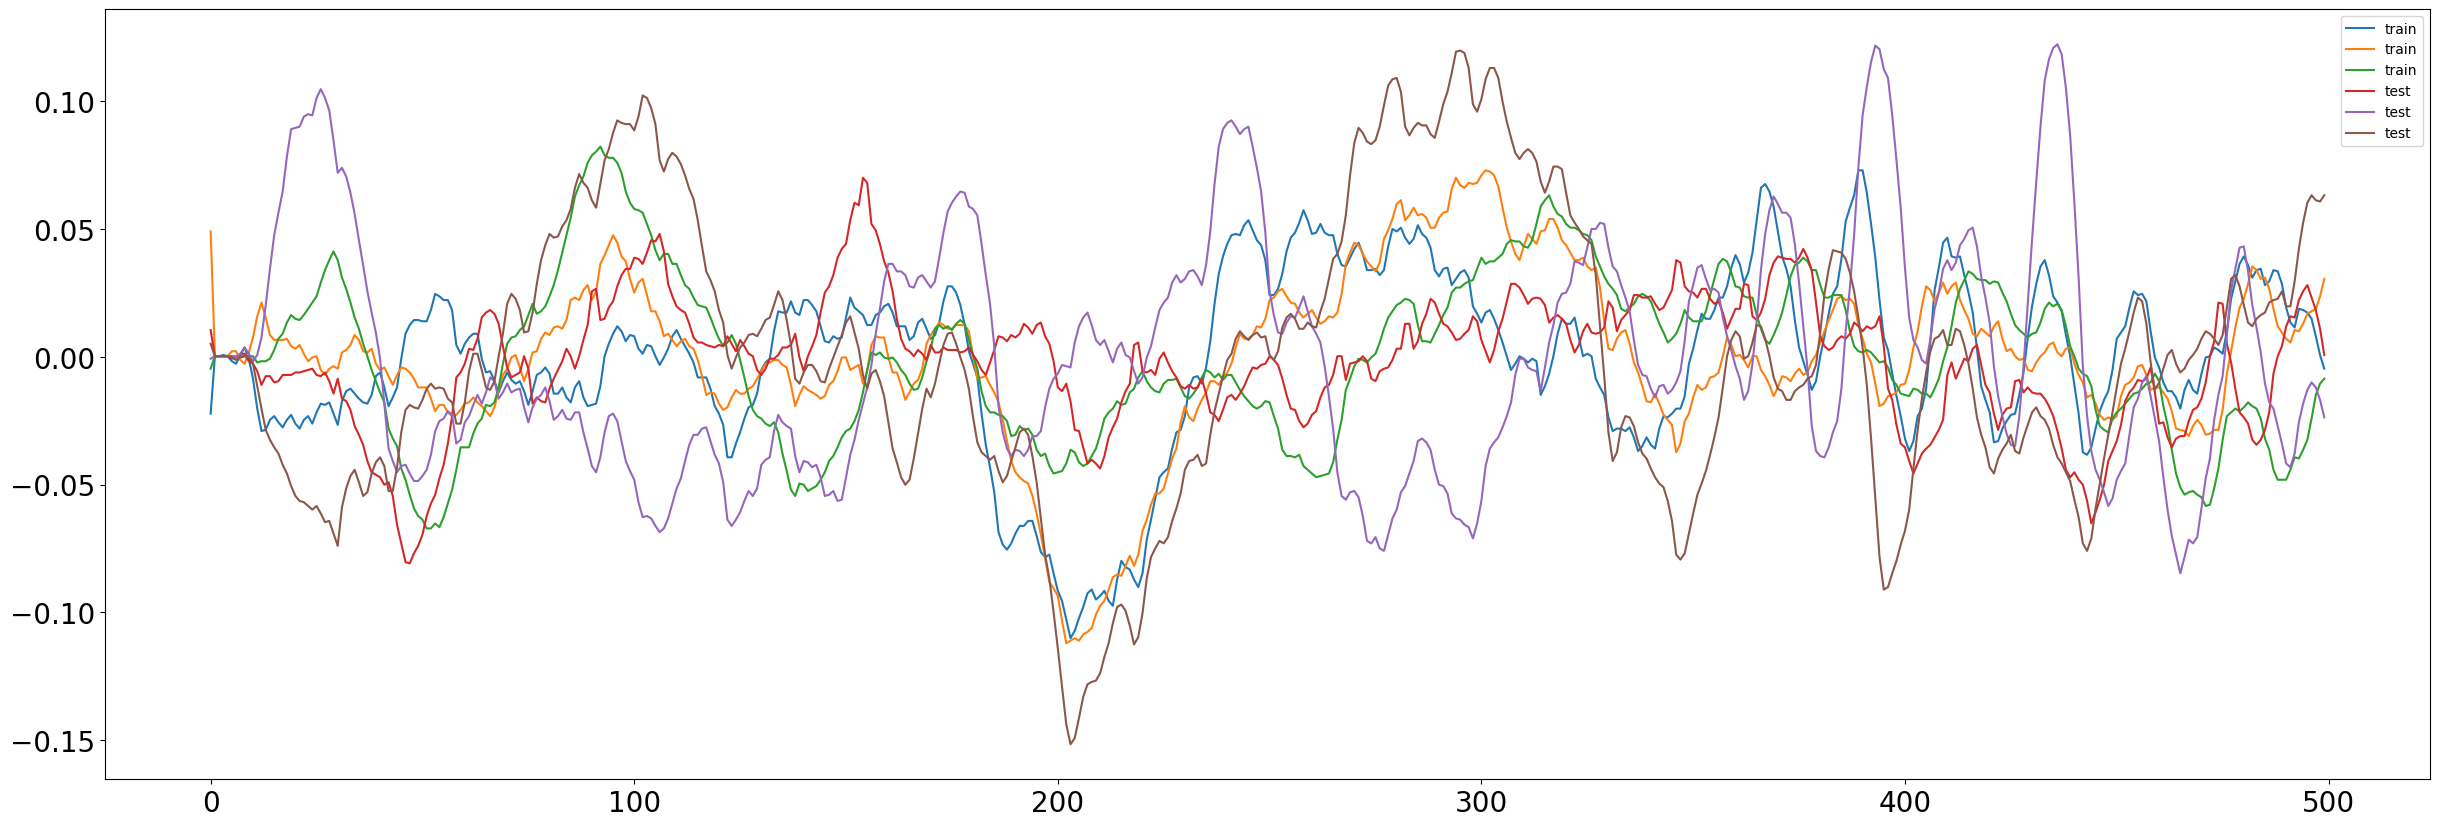

In [12]:
plt.figure(figsize=(30,10))
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
for i in range(3):
    plt.plot(train_input[i, :500], label='train')
for i in range(3):
    plt.plot(test_input[i, :500], label='test')
plt.legend()
plt.show()

We will start with a prediction which is
+ Univariate: we're using one signal to predict the future of that signal without considering other features. The opposite of this is multivariate, where multiple features are used in prediction (and multiple features can be simultaneously predicted)
+ 1-Step: we're predicting one step into the future, which can also be said as having a horizon of one sample.

# Baselines

TOUTE CETTE PARTIE EST STUPIDE AU POSSIBLE, PASSER DIRECTEMENT AUX RNNs

First we'll analyse the data and propose some simple baselines. We'll use **iterative prediction**, also known as walk-forward, to predict the next step at each timestep. The first baseline we'll use is called the naive baseline, which simply uses the previous value. We will start with a horizon of 1, meaning we have access to the previous timestep to predict the next one.

In [33]:
#Select the first EEG channel as the signal of interest
train_signal = train_input[0]

In [34]:
horizon = 1

# walk-forward validation
predictions = np.zeros(len(train_signal))
for t in range(len(predictions)-horizon):
    # make prediction
    predictions[t+horizon] = train_signal[t] # naive baseline

In [35]:
print("MSE of the naive baseline :",
      np.sqrt(mean_squared_error(train_signal[horizon:], predictions[:-horizon])))

MSE of the naive baseline : 0.015049891204863382


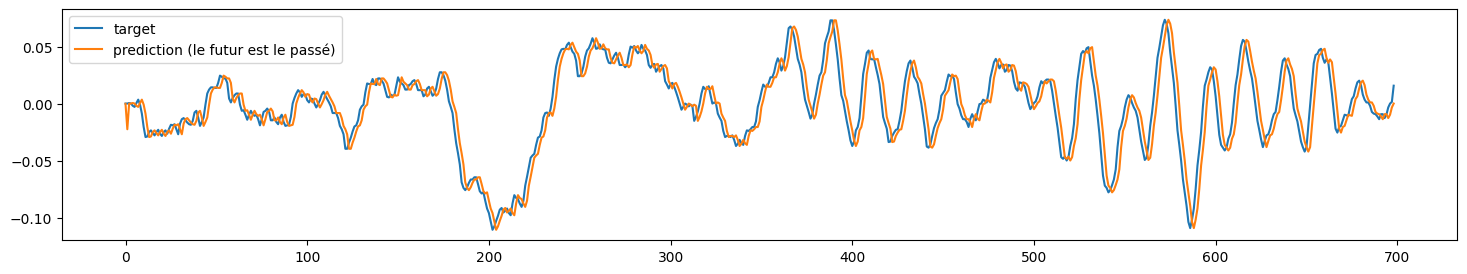

In [36]:
plt.figure(figsize=(18,3))
plt.plot(train_signal[horizon:700], label='target')
plt.plot(predictions[:700-horizon], label='prediction (le futur est le passé)')
plt.legend();

For a horizon of 1, the naive baseline works well. However, try increasing the horizon beyond 1ms and you'll notice that the performance degrades. Let's see if the historical data beyond one timestep can be useful. We'll start with a windowed approach, using the average of the past `W=5` timesteps as our prediction.

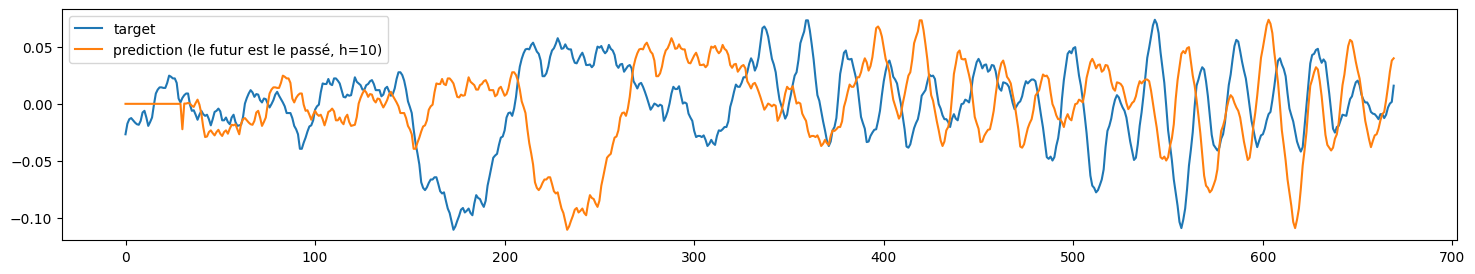

In [32]:
# horizon of 30
horizon = 30

# walk-forward validation
predictions = np.zeros(len(train_signal))
for t in range(len(predictions)-horizon):
    # make prediction
    predictions[t+horizon] = train_signal[t] # naive baseline

plt.figure(figsize=(18,3))
plt.plot(train_signal[horizon:700], label='target')
plt.plot(predictions[:700-horizon], label='prediction (le futur est le passé, h=10)')
plt.legend();

In [37]:
predictions = np.zeros(len(train_signal))
w = 50
for t in range(w, len(predictions)-horizon):
    # make prediction
    predictions[t+horizon] = train_signal[t-w:t].mean()

MSE of the moving average baseline : 0.03712365773862946


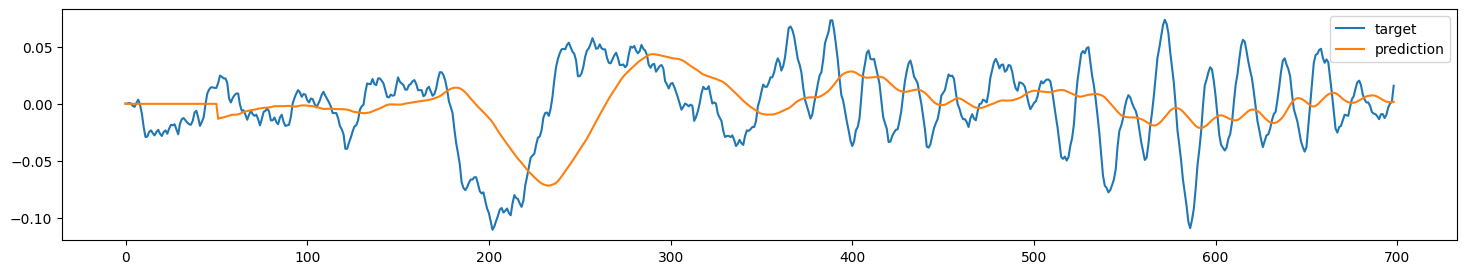

In [38]:
print("MSE of the moving average baseline :",
      np.sqrt(mean_squared_error(train_signal[horizon:], predictions[:-horizon])))
plt.figure(figsize=(18,3))
plt.plot(train_signal[horizon:700], label='target')
plt.plot(predictions[:700-horizon], label='prediction')
plt.legend();

While this captures the general trend of some parts of the data, the naive baseline is still superior in terms of root mean squared error. Another approach is to exponentially decrease the dependency on past predictions, known as exponential smoothing. The rate by which we decrease past predictions is the parameter $\alpha$.

In [39]:
def exponential_smoothing(alpha):
    predictions = np.zeros(len(train_signal))
    for t in range(len(predictions)-horizon):
    # make prediction
        predictions[t+horizon] = alpha * train_signal[t] + (1 - alpha) * predictions[t]
    return predictions

In [40]:
predictions_01 = exponential_smoothing(0.1)
print("MSE of the EMA baseline with alpha=0.1 :",
      np.sqrt(mean_squared_error(train_signal[horizon:], predictions_01[:-horizon])))

MSE of the EMA baseline with alpha=0.1 : 0.030224290553903934


In [41]:
predictions_05 = exponential_smoothing(0.5)
print("MSE of the EMA baseline with alpha=0.5 :",
      np.sqrt(mean_squared_error(train_signal[horizon:], predictions_05[:-horizon])))

MSE of the EMA baseline with alpha=0.5 : 0.020008720715069487


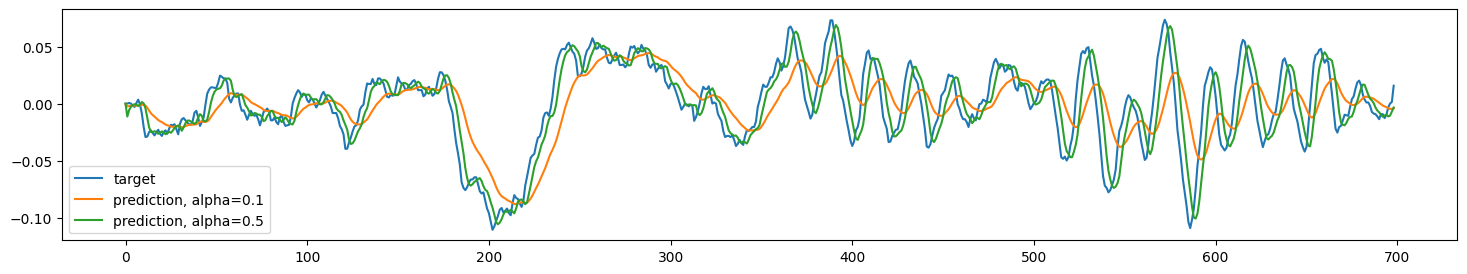

In [42]:
plt.figure(figsize=(18,3))
plt.plot(train_signal[horizon:700], label='target')
plt.plot(predictions_01[:700-horizon], label='prediction, alpha=0.1')
plt.plot(predictions_05[:700-horizon], label='prediction, alpha=0.5')
plt.legend();

While lower alpha values help predict the general trend of our data, their RMSE is worse than using very short history. So for this EEG data, we're still struggling to make good use of the historical data to predict future data. Instead of a single parameter for history decay, we'll instead use a recurrent neural network to inform our reliance on memory for prediction, and optimize the network parameters using Stochastic Gradient Descent.

# Recurrent Neural Networks

A simple recurrent neural network layer is very similar to a fully-connected feed-forward neural network layer; it has a set of weights $W_x$ mapping the previous layer $x$ to each neuron of the recurrent layer, a bias term for each neuron, and an activation function. However, a recurrent neural network also has state; specifically, each neuron connects to every other neuron in the same layer with a time delay of 1. This means that a recurrent neural network layer has a second weight matrix $W_s$ of size $n \times n$, where $n$ is the number of neurons in the recurrent layer.

$s_t = \tanh(W_{x} x + b_{x}  +  W_{s} s_{t-1} + b_{s})$

One way to consider these recurrent connections is by representing the previous activation functions of the recurrent layer as a hidden state, and using that hidden state as input to the network:

<img src="img/rnn.png">

Let's first observe the behavior of a single RNN layer using the `RNNCell` class from PyTorch. The documentation is [here](https://pytorch.org/docs/stable/generated/torch.nn.RNNCell.html).

In [43]:
rnn = nn.RNNCell(1, 10)

In [44]:
input_signal = torch.randn(1, 1)
hidden_state = torch.zeros(1, 10)
input_signal, hidden_state

(tensor([[0.0184]]), tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]]))

In [45]:
hidden_state = rnn(input_signal, hidden_state)
hidden_state

tensor([[ 0.3386, -0.0292, -0.2310, -0.0331, -0.2776, -0.0990, -0.1282,  0.4831,
         -0.0534,  0.4020]], grad_fn=<TanhBackward0>)

As we can see, the output of the `RNNCell` is the new hidden state. In order to predict the next value, we'll use a `Linear` model to map from this hidden state to a single output value.

In [ ]:
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, batch_size=1):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        self.input_size = input_size #n:
        self.batch_size = batch_size #n:
        self.rnn1 = nn.RNNCell(input_size, hidden_size)
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, inp, hidden):
        # predict over the different signals
        outputs = []
        for signal in inp.split(1, dim=1):
            hidden = self.rnn1(signal, hidden)
            output = self.linear(hidden)
            outputs += [output]
        outputs = torch.cat(outputs, dim=1)
        return outputs, hidden
    
    def init_hidden(self):
        return torch.zeros(self.batch_size, self.hidden_size, dtype=torch.double)

MSE of the RNN prediction with random weights : 0.21801160238064307


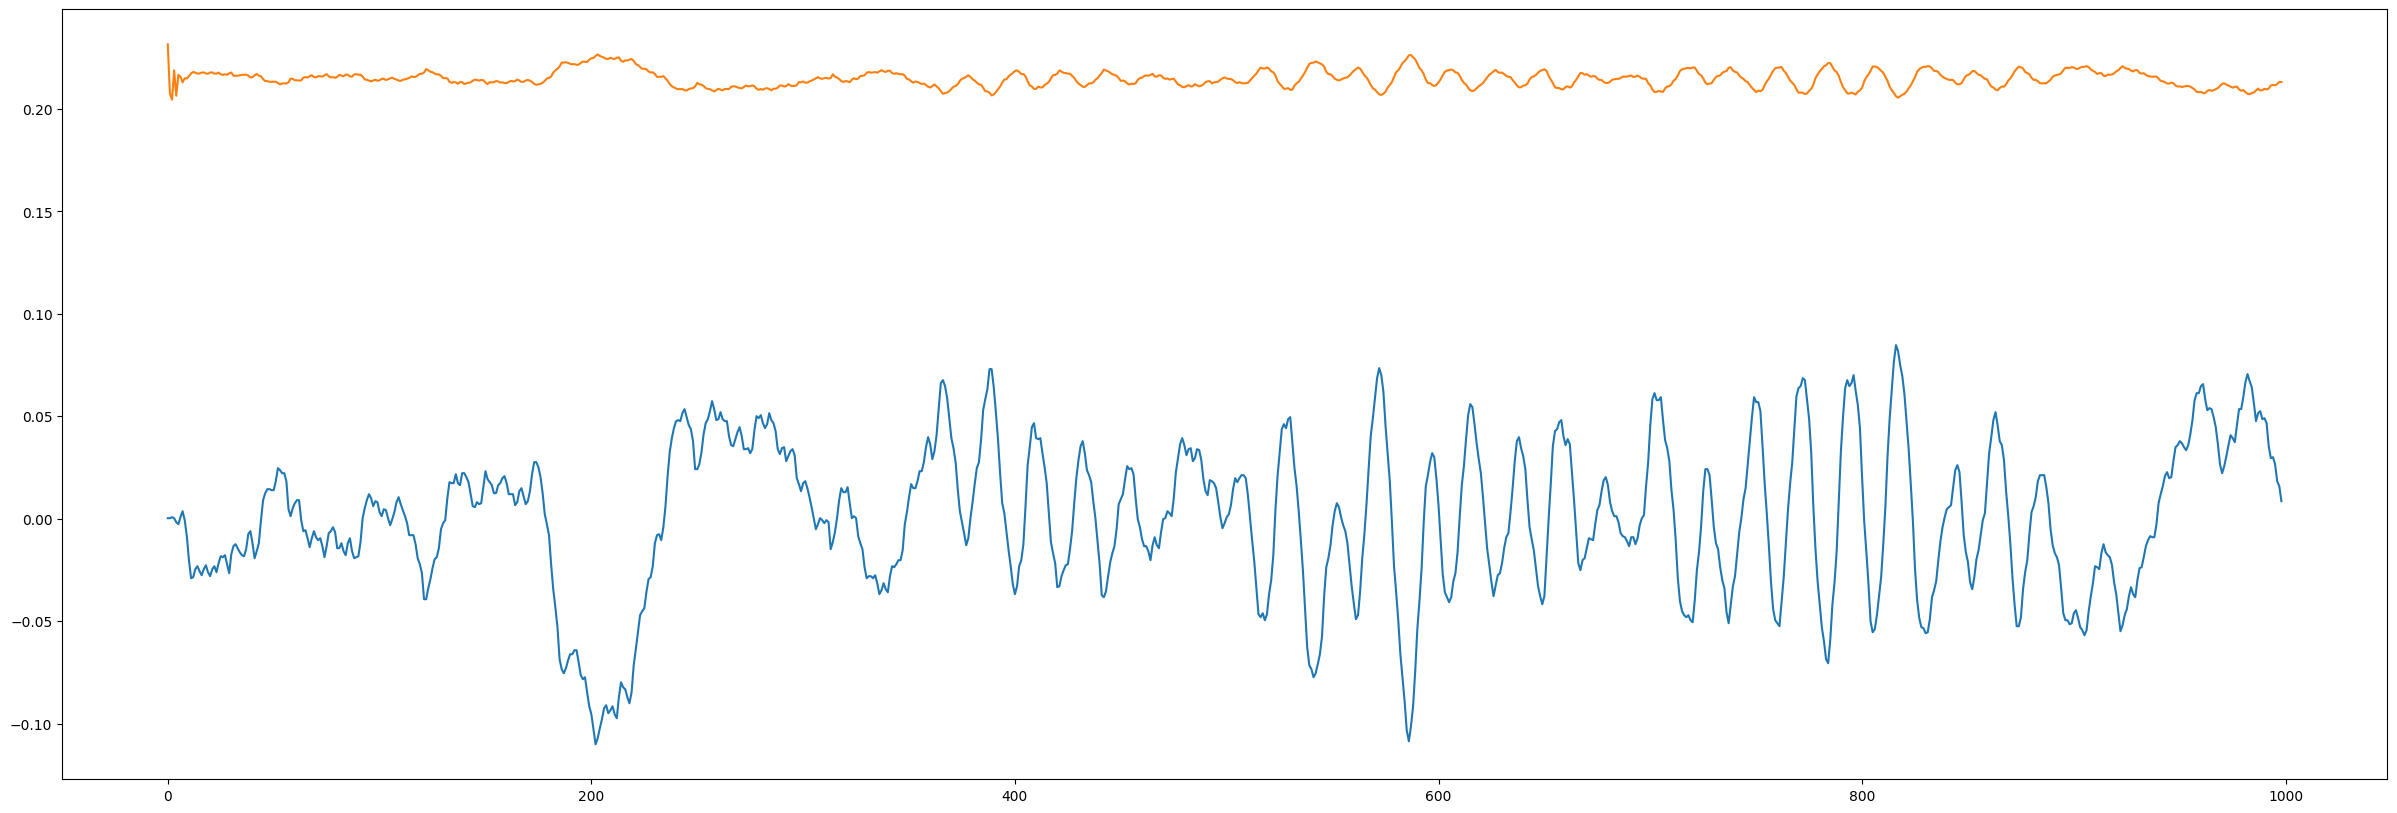

In [63]:
#initialize RNN and its initial recurrent state
n_hidden = 16
rnn = RNN(input_size=1, hidden_size=n_hidden, output_size=1).double()
hidden = rnn.init_hidden()

#run a prediction over the signal
with torch.no_grad():
    output, _ = rnn(train_input[0:1, :], hidden)
    y = output.detach().numpy()
    
print("MSE of the RNN prediction with random weights :",
      np.sqrt(mean_squared_error(train_input[0, 1:], y[0, :-1])))
plt.figure(figsize=(30,10))
plt.plot(train_input[0, 1:], label='real')
plt.plot(y[0, :-1], label='prediction');

This isn't very convincing, but remember that it is random weights. We'll soon get to training, but first let's increase the lookahead of our recurrent neural network. We'll try to predict 5 timesteps ahead.

The main difference with recurrent neural networks is that they depend on the previous state for the current state's computation. Instead of simply prediction $Y = f(x)$ as in feed-forward neural networks, recurrent networks do $Y_1 = f(x_1, f(x_0))$. Here's what an example "unrolled" RNN looks like, where the hidden state is carried over to next timestep.

<img src="img/unrolled.png">

<div class="alert alert-success">
Exercise 1
    
Include a look-ahead of `future` timesteps in your RNN model by completing the class below. Make sure to continuously update the `hidden` state.
</div>

In [ ]:
# on pourrait aussi mettre future en argument du forward
class RNNf(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, batch_size=1, future=1):
        super(RNNf, self).__init__()
        self.hidden_size = hidden_size
        self.input_size = input_size #n:
        self.batch_size = batch_size #n:
        self.future = future #n:
        self.rnn1 = nn.RNNCell(input_size, hidden_size)
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, inp, hidden):
        # predict over the different signals
        outputs = []
        for signal in inp.split(1, dim=1):
            hidden = self.rnn1(signal.transpose(0, 1), hidden)
            output = self.linear(hidden)
            outputs += [output.transpose(0,1)]

        # predict the future : one step further at a time
        for f in range(self.future) :
            hidden = self.rnn1(output, hidden)
            output = self.linear(hidden)
            outputs += [output.transpose(0,1)] # le futur s'allonge

        outputs = torch.cat(outputs, dim=1)
        return outputs, hidden
    
    def init_hidden(self):
        return torch.zeros(self.batch_size, self.hidden_size, dtype=torch.double)

MSE of the RNN prediction with random weights : 0.04409376044215703


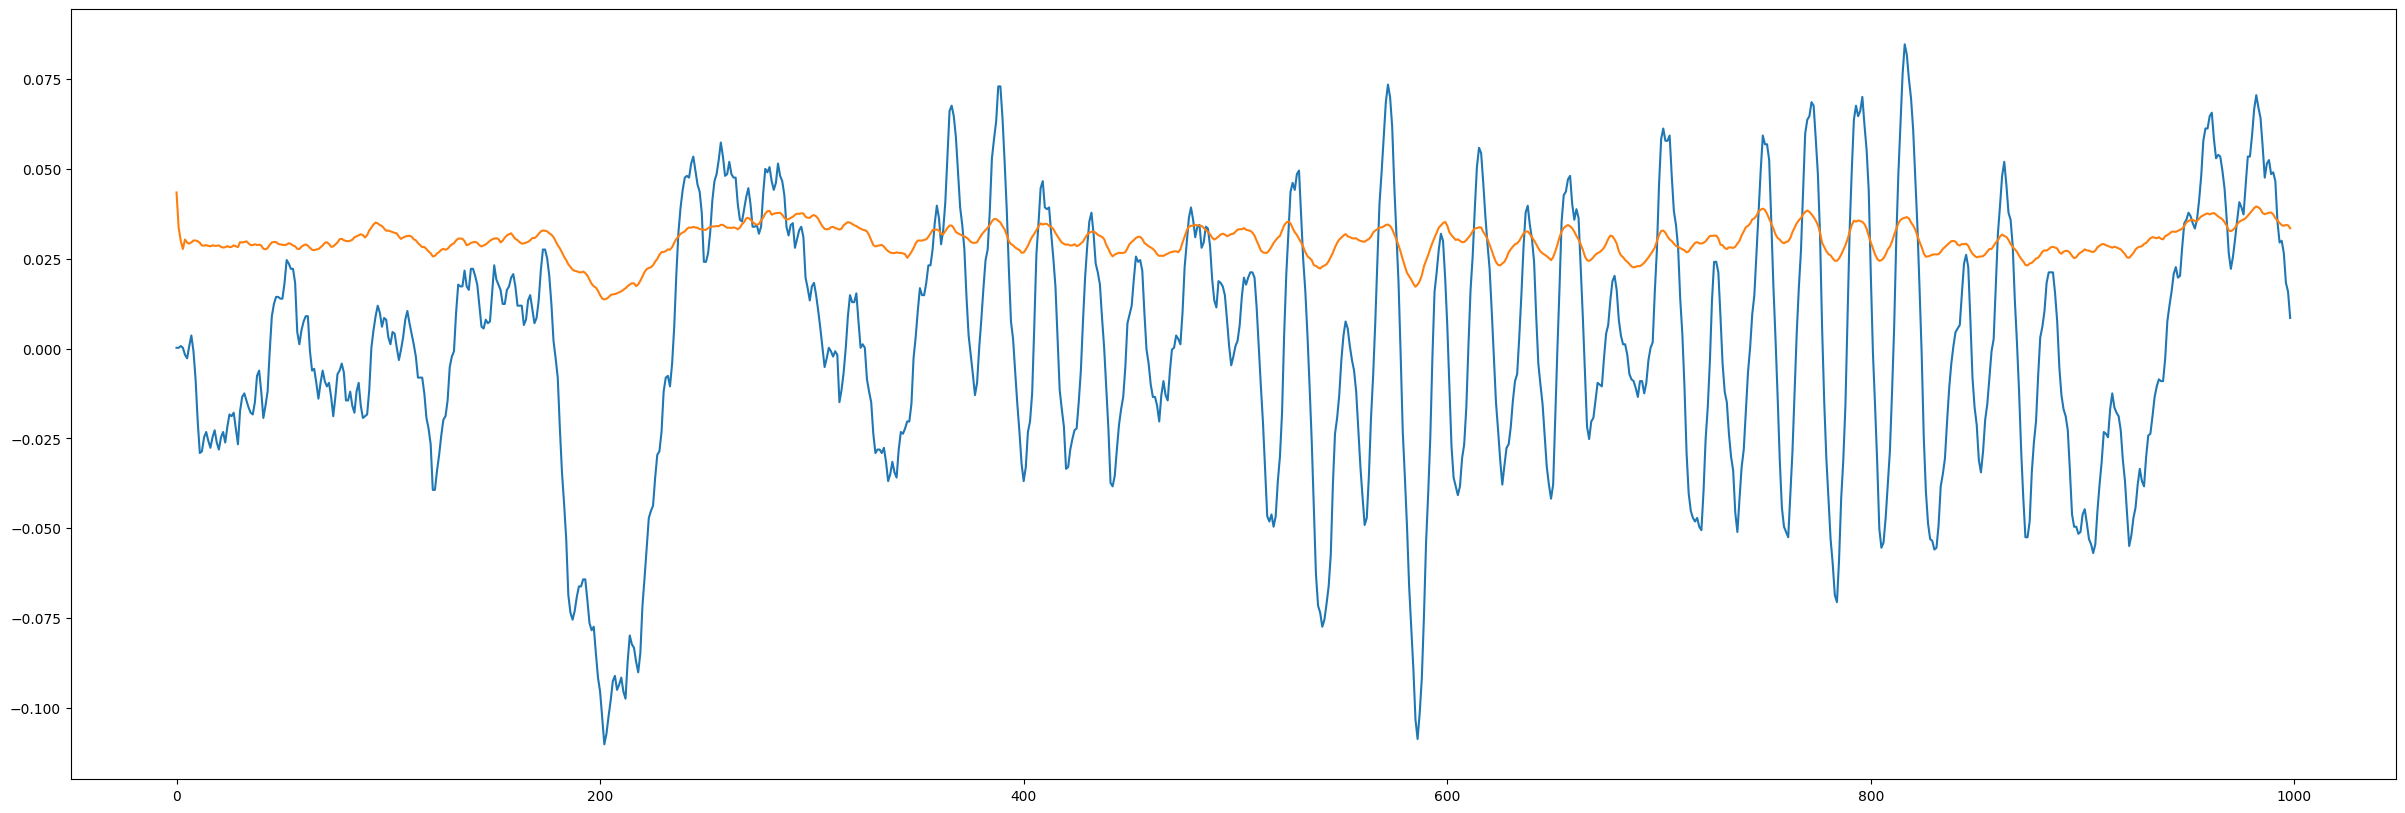

In [81]:
horizon=1
rnn = RNNf(3, n_hidden, 3, future=horizon).double()
hidden = rnn.init_hidden()



with torch.no_grad():
    output, hidden = rnn(train_input, hidden)
    y = output.detach().numpy()

print("MSE of the RNN prediction with random weights :",
      np.sqrt(mean_squared_error(train_input[0, horizon:], y[0, horizon:-horizon])))
plt.figure(figsize=(30,10))
plt.plot(train_input[0, horizon:], label='real')
plt.plot(y[0, horizon:-horizon], label='prediction');

## Backpropagation through time

Our network doesn't do very well, but it's using random weights. In order to train it, we'll need to calcuate the gradient throughout the iterative process. This is known as **backpropagation through time**, and it relies on the computation of not just the current timestep, but all previous timesteps as well.

<img src="img/bptt.png">

In [110]:
horizon=1
n_hidden=64

rnn = RNNf(3, n_hidden, 3, future=horizon).double()
criterion = nn.MSELoss()
optimizer = optim.LBFGS(rnn.parameters(), lr=0.8)

In [111]:
# training step through all data
def closure():
    optimizer.zero_grad()
    hidden = rnn.init_hidden()
    out, hidden = rnn(train_input[:, :-horizon], hidden)
    loss = criterion(out[:, :-horizon], train_input[:, horizon:])
    print('loss:', loss.item())
    loss.backward()
    return loss

In [112]:
optimizer.step(closure)

loss: 0.018309086321967122
loss: 0.010741055342478148
loss: 0.0018303656572610906
loss: 0.0012069728247883754
loss: 0.001179811176799576
loss: 0.001177902443551489
loss: 0.0011764914842556662
loss: 0.0011726423797560942
loss: 0.0011639704505608066
loss: 0.0011439258842407985
loss: 0.0010977375706458315
loss: 0.0009813347298802471
loss: 0.000503435037342377
loss: 0.003963433096596689
loss: 0.00021538031892919709
loss: 0.00020498720889742817
loss: 0.00019306760614044597
loss: 0.00018994566670121402
loss: 0.00018778708404829688
loss: 0.00018576171006380013


tensor(0.0183, dtype=torch.float64, grad_fn=<MseLossBackward0>)

In [113]:
hidden=rnn.init_hidden()
with torch.no_grad():
    output, hidden = rnn(train_input, hidden)
    y = output.detach().numpy()

MSE of the RNN prediction after training: 0.015488232866303232


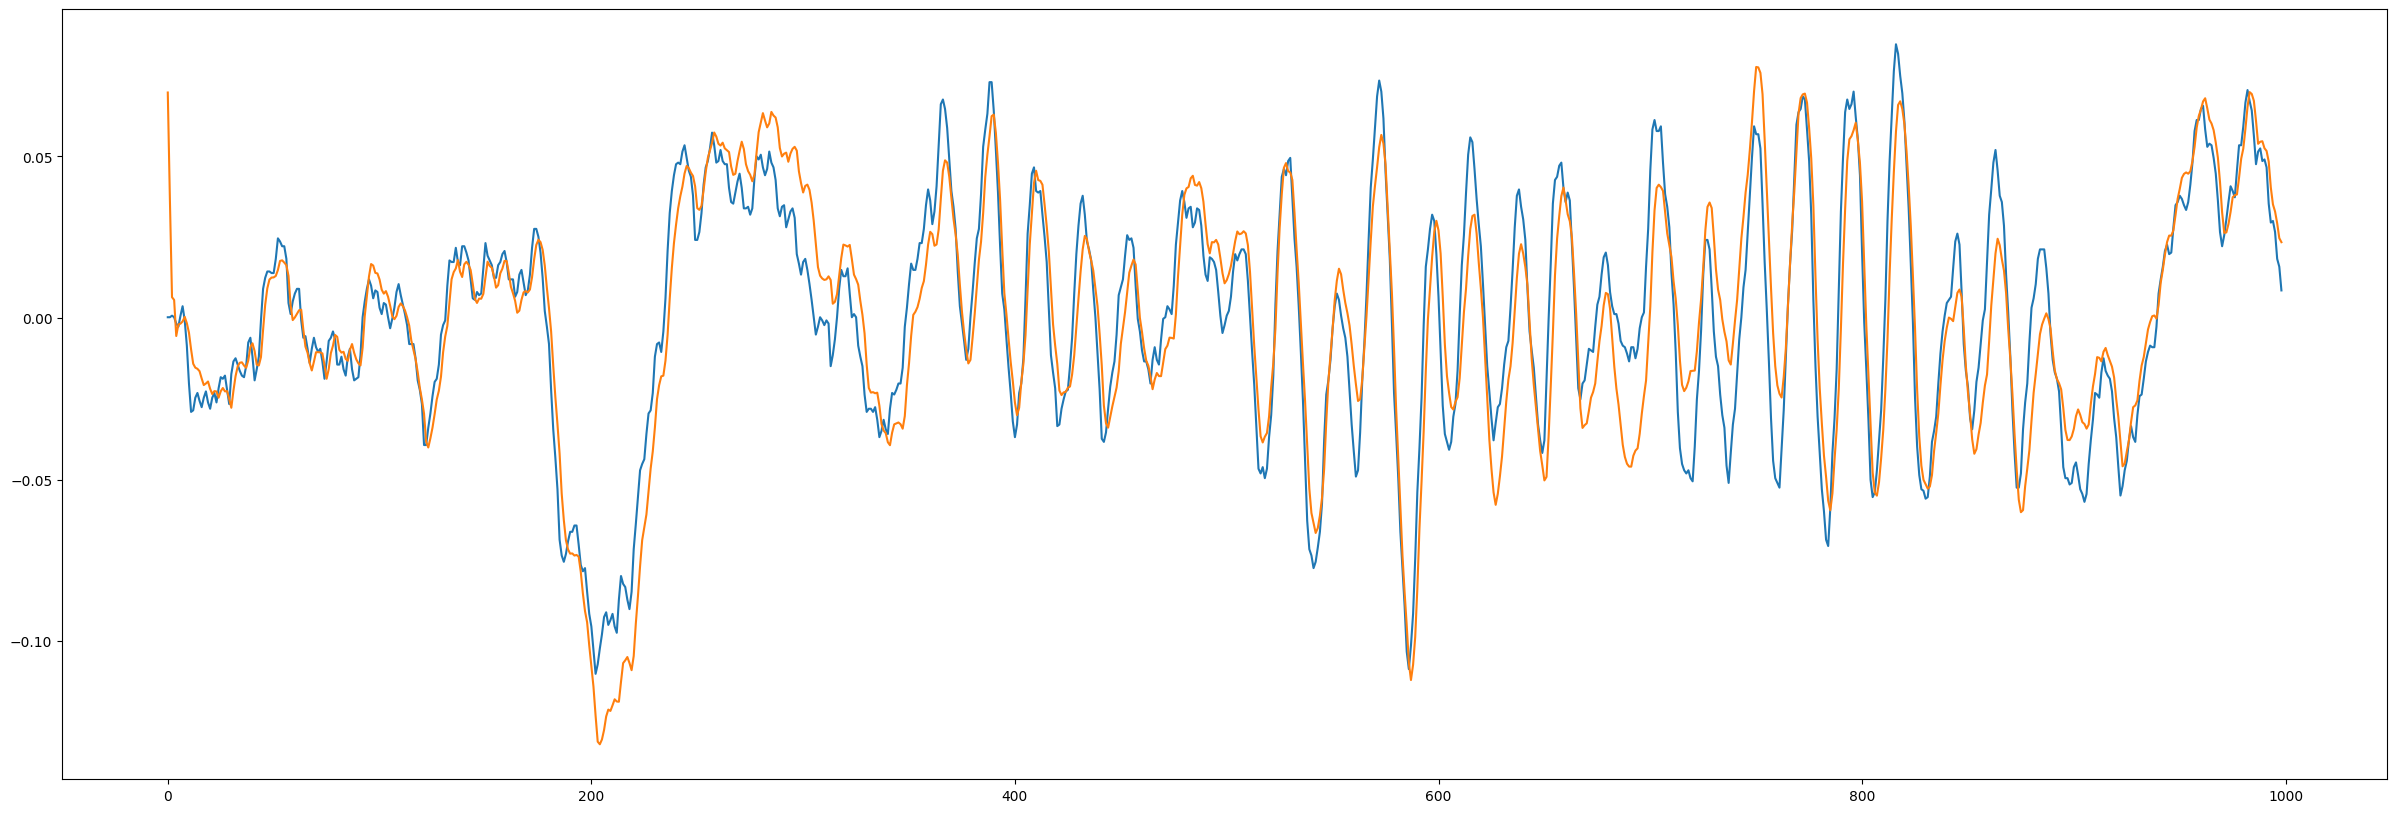

In [114]:
target = train_input[0, horizon:]
print("MSE of the RNN prediction after training:",
      np.sqrt(mean_squared_error(target, y[0, :len(target)])))
plt.figure(figsize=(30,10))
plt.plot(target, label='real')
plt.plot(y[0, :len(target)], label='prediction');

NB : c'est une validation sur le jeu d'entrainement. Elle n'est pas parfaite, donc on a une prédiction qui n'est pas si folle que ça. En augmentant le nombre de neurones (16->32->64), c'est mieux mais ça reste de la validation sur du train set.

In [103]:
hidden=rnn.init_hidden()
with torch.no_grad():
    output, hidden = rnn(test_input, hidden)
    y = output.detach().numpy()

MSE of the RNN prediction after training: 0.03565538750689453


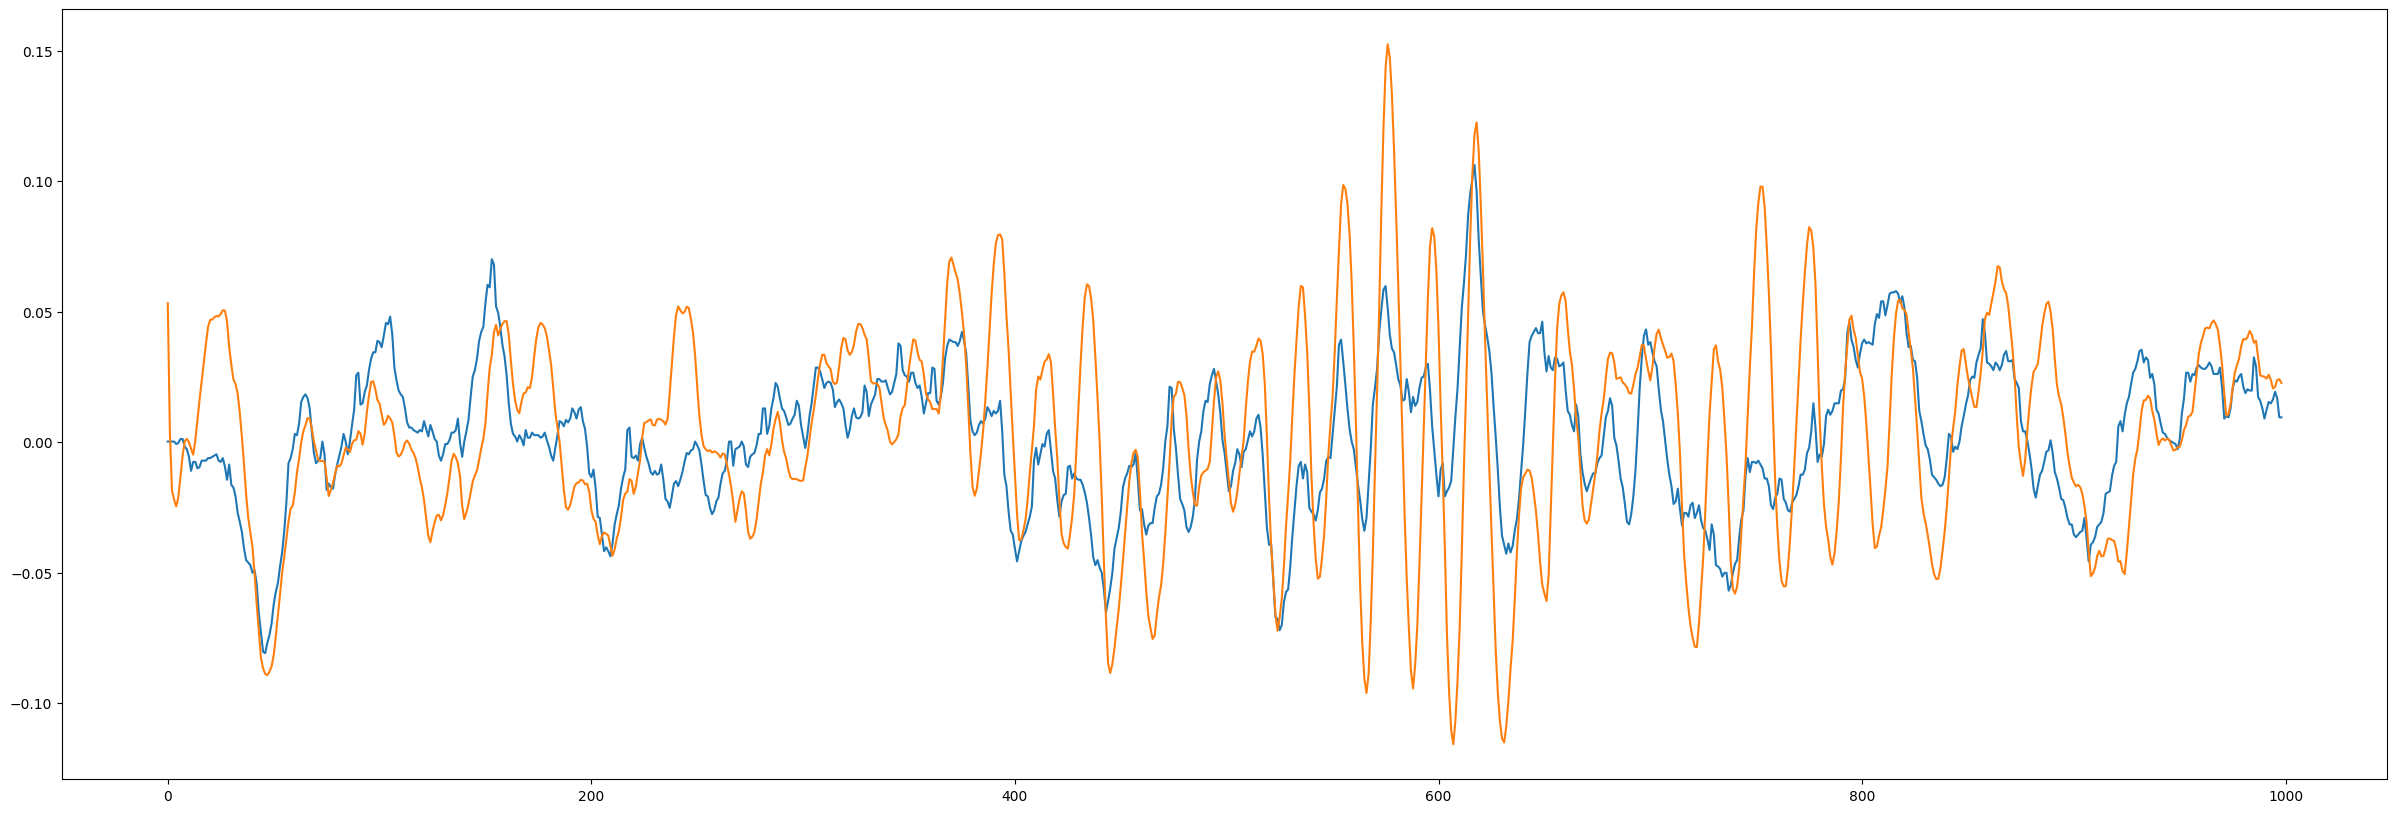

In [104]:
target = test_input[0, horizon:]
print("MSE of the RNN prediction after training:",
      np.sqrt(mean_squared_error(target, y[0, :len(target)])))
plt.figure(figsize=(30,10))
plt.plot(target, label='real')
plt.plot(y[0, :len(target)], label='prediction');

<div class="alert alert-success">
Exercise 2:

Increase the look-ahead of your model during training. Make sure to align the `target` data with the output of your model (ie, advanced by `N` timesteps). How far ahead can your model predict with good accuracy?
</div>

Ça marche MAL.

# Long Short-Term Memory

A more complex recurrent neural network, which actually predates much of the current era of deep learning, is called the Long Short-Term Memory unit. This unit has multiple different internal states which are transformed to retain only the pertinent information.

Gers, Felix A., Jürgen Schmidhuber, and Fred Cummins. "Learning to forget: Continual prediction with LSTM." (1999): 850-855.

<img src='img/lstm.png'>

cf slides

On ajoute une cellule mémoire à l'état interne. La mémoire n'est pas affectée par une fonction d'activation, donc n'est par normalisée, et donc ne disparaît pas au fil des pas de temps. Les LSTM gèrent donc beaucoup mieux les lognues fenêtres, et conservent les informations plus longtemps.

Porte f : forget
Porte o : output
Porte i : input

Il y a beaucoup plus de poids dans ce système : 4 fois plus que dans un RNN. Mais les RNNs sont très petits (notamment par rapport à un transformer), donc ça reste léger.

LSTM est plus utilisable que RNN. RNN est passablement dépassé. Les transformers ont besoin de manger plus de données et consomment plus de calcul (complexité en longueur de la séquence au carré), donc parfois LSTM joue, notamment pour des applications embarquées (ou application hors GPU).

$$
i_t = \sigma(W_{xi}x_t + W_{hi}h_{t-1} + W_{ci}c_{t-1}+b_i)\\
f_t = \sigma(W_{xf}x_t + W_{hf}h_{t-1} + W_{cf}c_{t-1}+b_f)\\
c_t = f_tc_{t-1}+i_t\tanh(W_{xc}x_t + W_{hc}h_{t-1} + b_c)\\
o_t = \sigma(W_{xo}x_t + W_{ho}h_{t-1} + W_{co}c_{t-1}+b_o)\\
h_t = o_t\tanh(c_t)
$$

<div class="alert alert-success">
Exercise 3

Modify your model from part exercise 2 to use the PyTorch `LSTMCell` classes. Be aware of the multiple return values from an LSTM - the hidden state and cell state. The documentation is [here](https://pytorch.org/docs/stable/generated/torch.nn.LSTMCell.html). Compare your test prediction error against the RNN model and against the naive baseline. 

</div>

In [ ]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(LSTM, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.lstm1 = nn.LSTMCell(1, hidden_size)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, inp, h_t, c_t, future=0):
        outputs = []
        for signal in inp.split(1, dim=1):
            h_t, c_t = self.lstm1(signal, (h_t, c_t))
            output = self.linear(h_t)
            outputs += [output]
        for i in range(1, future):# if we should predict the future
            h_t, c_t = self.lstm1(output, (h_t, c_t))
            output = self.linear(h_t)
            outputs += [output]
        outputs = torch.cat(outputs, dim=1)
        return outputs, h_t, c_t

    def init_hidden(self):
        return (torch.zeros(self.input_size, self.hidden_size, dtype=torch.double),
                torch.zeros(self.input_size, self.hidden_size, dtype=torch.double))

In [ ]:
lstm = LSTM(3, n_hidden, 3).double()
criterion = nn.MSELoss()
optimizer = optim.LBFGS(lstm.parameters(), lr=0.8)

In [ ]:
# training step through all data
def closure():
    optimizer.zero_grad()
    h_t, c_t = lstm.init_hidden()
    out, h_t, c_t = lstm(train_input[:, :-horizon], h_t, c_t, future=horizon)
    loss = criterion(out[:, :-horizon+1], train_input[:, horizon:])
    print('loss:', loss.item())
    loss.backward()
    return loss

In [ ]:
optimizer.step(closure)

In [ ]:
h_t, c_t = lstm.init_hidden()
with torch.no_grad():
    outputs, h_t, c_t = lstm(train_input, h_t, c_t, future=horizon)
    y = outputs.detach().numpy()

In [ ]:
target = train_input[0, horizon:]
print("MSE of the LSTM prediction after training:",
      np.sqrt(mean_squared_error(target, y[0, :len(target)])))
plt.figure(figsize=(30,10))
plt.plot(target, label='real')
plt.plot(y[0, :len(target)], label='prediction');

In [ ]:
h_t, c_t = lstm.init_hidden()
with torch.no_grad():
    outputs, h_t, c_t = lstm(test_input, h_t, c_t, future=horizon)
    y = outputs.detach().numpy()

In [ ]:
target = test_input[0, horizon:]
print("MSE of the LSTM prediction after training:",
      np.sqrt(mean_squared_error(target, y[0, :len(target)])))
plt.figure(figsize=(30,10))
plt.plot(target, label='real')
plt.plot(y[0, :len(target)], label='prediction');

<div class="alert alert-info">
Truncated BPTT

So far, we've been iterating through the entire dataset each epoch. In order to split the data into batches, what would need to be done? How could the hidden state of your recurrent networks be preserved between batches?
</div>

<div class="alert alert-success">
Bonus Exercise

Another recurrent layer type is the Gated Recurrent Unit. It was designed to solve the issue of vanishing gradients in LSTMs. [Here](https://arxiv.org/pdf/1412.3555.pdf) is an empirical study of the layer types. Try replacing your LSTM with a GRU to see if it changes your results.
</div>

If you'd like to know more about time-series prediction, [this notebook](https://github.com/marcopeix/stock-prediction/blob/master/Stock%20Prediction.ipynb) gives an example of more complex classical prediction models, notably Seasonal ARIMA.

In the next class, we'll see one of the most popular uses of LSTMs currently, in the context of [Natural Language Processing](https://arxiv.org/pdf/1810.04805.pdf).